In [1]:
import numpy as np, os, h5py
import cupy as cp
import matplotlib.pyplot as plt

import astropy.units as u
import astropy.constants as cst

from glob import glob
from tqdm import tqdm
from moviepy.editor import ImageSequenceClip

In [2]:
def get_accelleration(pos, mass, G, softening):
    """ Calculate the acceleration on each particle due to Newton's Law 
        
        Inputs:
            - pos (ndarray): array position of the particles with shape (N,3)
            - mass (ndarray): array mass of the particle with shape (N,1)
            - G (float): Newton Gravitational constant in the same units as the velocity and postion of the particles
            - softening (float): the softening length to avoid numerical infinity
        Return:
            - a (ndarray): array of the accelleration of the particles with shape (N,3)
    """
    # positions r = [x,y,z] for all particles
    r_x = pos[:,0:1]
    r_y = pos[:,1:2]
    r_z = pos[:,2:3]

    # matrix that stores all pairwise particle separations: r_j - r_i
    rdx = r_x.T - r_x
    rdy = r_y.T - r_y
    rdz = r_z.T - r_z
    
    # matrix that stores 1/r^3 for all particle pairwise particle separations 
    inv_r3 = (rdx**2 + rdy**2 + rdz**2 + softening)**(-1.5)
    
    a_x = G * (rdx * inv_r3) @ mass
    a_y = G * (rdy * inv_r3) @ mass
    a_z = G * (rdz * inv_r3) @ mass
    
    # pack together the acceleration components
    #a = np.vstack((a_x, a_y, a_z))
    a = np.array([a_x, a_y, a_z]).T

    return a

## Get coordiantes of planets

In [3]:
from calculate_coord_astropy import solar_system

HELIOCENTRIC COORDINATES at 2025-08-01T12:00:00 (ICRS frame)

Sun:
  Position (AU)   : x = 0.000000 AU, y = 0.000000 AU, z = 0.000000 AU
  Velocity (km/s) : vx = 0.000000 AU / d, vy = 0.000000 AU / d, vz = 0.000000 AU / d

Mercury:
  Position (AU)   : x = 0.272182 AU, y = -0.273220 AU, z = -0.174164 AU
  Velocity (km/s) : vx = 0.015835 AU / d, vy = 0.017905 AU / d, vz = 0.007924 AU / d

Venus:
  Position (AU)   : x = 0.616427 AU, y = 0.359613 AU, z = 0.122816 AU
  Velocity (km/s) : vx = -0.010653 AU / d, vy = 0.015393 AU / d, vz = 0.007600 AU / d

Earth:
  Position (AU)   : x = 0.640721 AU, y = -0.722151 AU, z = -0.313041 AU
  Velocity (km/s) : vx = 0.013060 AU / d, vy = 0.009911 AU / d, vz = 0.004296 AU / d

Mars:
  Position (AU)   : x = -1.475531 AU, y = -0.604110 AU, z = -0.237292 AU
  Velocity (km/s) : vx = 0.006155 AU / d, vy = -0.010499 AU / d, vz = -0.004982 AU / d

Jupiter:
  Position (AU)   : x = -0.558915 AU, y = 4.706532 AU, z = 2.030952 AU
  Velocity (km/s) : vx = -0.007596

# N-body simulation

Simulation parameters and constants

In [4]:
# time start, time-step and time end
t_start, t_end, dt = (0.0*u.day).value, (500*365.0*u.day).value, (1.*u.day).value

tt = np.arange(t_start, t_end+dt, dt)*u.day

# softening length
softening = (1e-12 *u.AU).value

# Newton's Gravitational constant
G_grav = cst.G.to('AU^3/(Msun*day^2)').value

In [17]:
# values from planets
colors = ['yellow', 'grey', 'violet', 'deepskyblue', 'tomato', 'tab:orange', 'khaki', 'cyan', 'blue', 'chocolate']

mass = np.array([solar_system[key]['mass'] for key in solar_system.keys()]) #* u.Msun
pos = np.array([solar_system[key]['position'] for key in solar_system.keys()]) #* u.AU
vel = np.array([solar_system[key]['velocity'] for key in solar_system.keys()]) #* u.AU/u.day

# Number of particles
N = pos.shape[0]

print(N)
print(solar_system.keys(), pos.shape)
print(mass, mass.shape)
print(pos, pos.shape)
print(vel, vel.shape)

10
dict_keys(['Sun', 'Mercury', 'Venus', 'Earth', 'Mars', 'Jupiter', 'Saturn', 'Uranus', 'Neptune', 'Pluto']) (10, 3)
[1.00004533e+00 1.66017080e-07 2.44793595e-06 3.00359100e-06
 3.22725213e-07 9.54632155e-04 2.85826382e-04 4.36580009e-05
 5.15049747e-05 6.55297491e-09] (10,)
[[  0.           0.           0.        ]
 [  0.27218193  -0.27321982  -0.17416404]
 [  0.61642696   0.35961302   0.12281636]
 [  0.64072082  -0.72215059  -0.31304089]
 [ -1.47553053  -0.60411016  -0.23729179]
 [ -0.55891484   4.7065319    2.03095216]
 [  9.54015191  -0.39516514  -0.57401619]
 [ 10.39819248  15.18240649   6.50228046]
 [ 29.88075619   0.3084416   -0.61761758]
 [ 18.81253995 -26.44935324 -13.9204908 ]] (10, 3)
[[ 0.00000000e+00  0.00000000e+00  0.00000000e+00]
 [ 1.58350251e-02  1.79054265e-02  7.92395559e-03]
 [-1.06527851e-02  1.53925094e-02  7.60015707e-03]
 [ 1.30596139e-02  9.91053667e-03  4.29639740e-03]
 [ 6.15505896e-03 -1.04987617e-02 -4.98155729e-03]
 [-7.59629546e-03 -4.94518588e-04 -2.7

In [6]:
# calculate initial gravitational accelerations
acc = get_accelleration(pos, mass, G_grav, softening)

# number of timesteps
Nt = int(np.ceil(t_end/dt))

# save particle orbits
pos_save = np.zeros((N,3,Nt+1))
pos_save[:,:,0] = pos

t_all = np.arange(Nt+1)*dt
t = t_start

# Simulation Main Loop
for i in tqdm(range(Nt)):
    # (1/2) kick
    vel += acc * dt/2.0

    # drift
    pos += vel * dt

    # update accelerations
    acc = get_accelleration(pos, mass, cst.G.to('AU^3/(Msun*day^2)').value, softening)

    # (1/2) kick
    vel += acc * dt/2.0

    # update time
    t += dt

    # save energies, positions for plotting trail
    pos_save[:,:,i+1] = pos

100%|█████████████████████████████████| 182500/182500 [00:25<00:00, 7162.37it/s]


## Earth-Sun distance

(-0.1, 10.0)

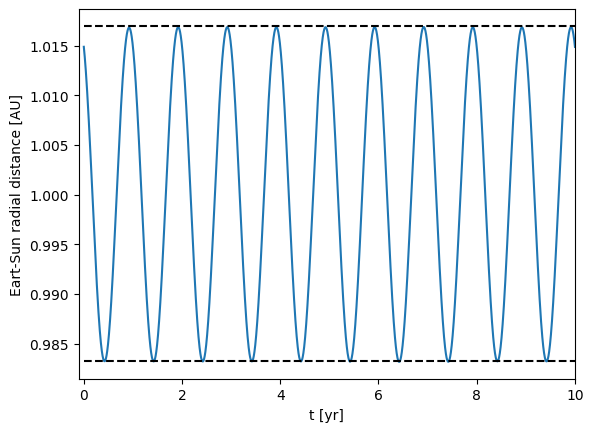

In [16]:
earth_sun_dist = np.linalg.norm((pos_save[0] - pos_save[3]), axis=0)

plt.plot(tt.to('yr'), earth_sun_dist)
plt.hlines(y=1.017, xmin=0, xmax=tt.to('yr').value.max(), ls='--', color='k')
plt.hlines(y=0.98327, xmin=0, xmax=tt.to('yr').value.max(), ls='--', color='k')

plt.xlabel(r't [yr]')
plt.ylabel(r'Eart-Sun radial distance [AU]')
plt.xlim(-0.1, 10)

## Plot for Video

  0%|                                   | 199/182501 [00:43<11:01:14,  4.59it/s]


KeyboardInterrupt: 

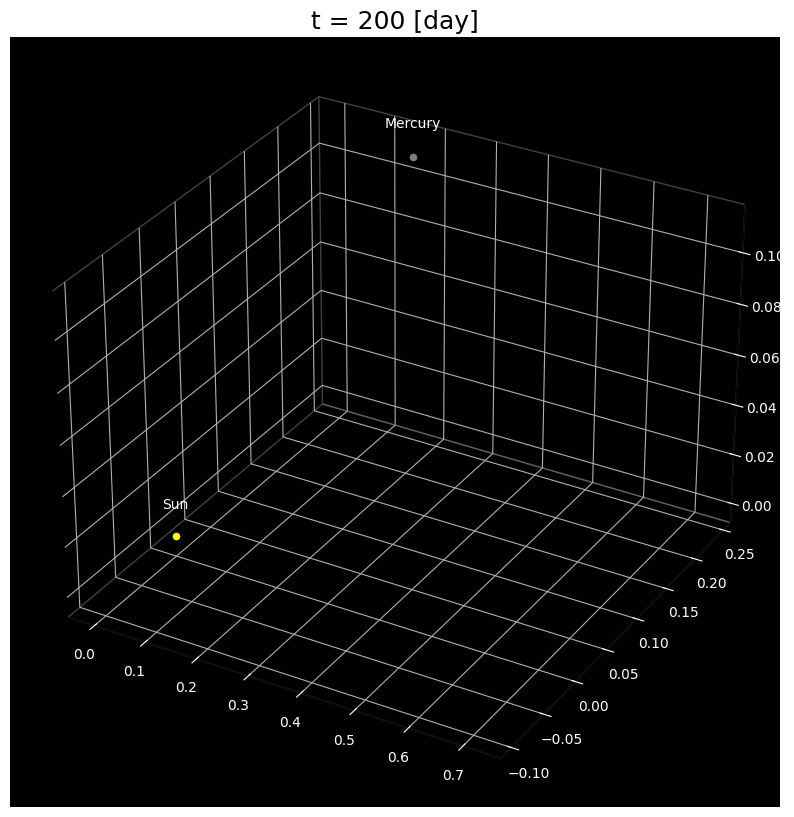

In [50]:
path_out = './solar_snapshot/'
#i_start = len(glob(path_out+'snapshot_*.png'))

i_start, i_end = 0, Nt+1
xyz_scale = 10 #28

for i in tqdm(range(i_start, i_end)):
    fig = plt.figure(figsize=(10, 10))
    ax = fig.add_subplot(projection='3d')
    ax.set_title('t = %d [day]' %((i+1)*dt), color='black', fontsize=18)
    
    ax.grid(True, color='grey', alpha=0.2)  # Grid lines with transparency    
    ax.xaxis.pane.fill = False
    ax.yaxis.pane.fill = False
    ax.zaxis.pane.fill = False
    
    ax.xaxis.pane.set_edgecolor('grey')
    ax.yaxis.pane.set_edgecolor('grey')
    ax.zaxis.pane.set_edgecolor('grey')
    ax.xaxis.label.set_color('white')
    ax.yaxis.label.set_color('white')
    ax.zaxis.label.set_color('white')

    ax.tick_params(axis='x', colors='white')
    ax.tick_params(axis='y', colors='white')
    ax.tick_params(axis='z', colors='white')
    ax.set_facecolor('black')
    
    x, y, z = pos_save[...,i].T
    """
    if(i < 25):
        x_tail, y_tail, z_tail = np.moveaxis(pos_save[...,:i+1], 1, 0)
    else:
        x_tail, y_tail, z_tail = np.moveaxis(pos_save[...,i-60:i], 1, 0)
    """
    
    for j, p_name in enumerate(solar_system.keys()):
        ax.scatter(x[j], y[j], z[j], marker='o', s=20, color=colors[j])
        ax.text(x[j], y[j], z[j]+0.01, p_name, color='white', fontsize=10, ha='center', va='bottom')
        #ax.scatter(x_tail[j], y_tail[j], z_tail[j], marker='o', s=1, color=colors[j], alpha=0.2)
    
    pos_cm = np.mean(pos_save[...,i]*mass[...,None], axis=0)/np.mean(mass)
    
    #ax.set_xlim(pos_cm[1]-xyz_scale, pos_cm[0]+xyz_scale), ax.set_ylim(pos_cm[1]-xyz_scale, pos_cm[1]+xyz_scale), ax.set_zlim(pos_cm[2]-xyz_scale, pos_cm[2]+xyz_scale)
    ax.set_xlim(x[0]-xyz_scale, x[0]+xyz_scale), ax.set_ylim(y[0]-xyz_scale, y[0]+xyz_scale), ax.set_zlim(z[0]-xyz_scale, z[0]+xyz_scale)
    
    ax.set_xlabel('x [AU]'), ax.set_ylabel('y [AU]'), ax.set_zlabel('z [AU]')
    
    plt.savefig(path_out+'snapshot_%d.png' %i, bbox_inches='tight')
    plt.clf(), plt.close()

## Create GIF

In [11]:
def CreateMovie(filename, array, fps=5, scale=1., fmt='avi'):
    ''' Create and save a gif or video from array of images.
        Parameters:
            * filename (string): name of the saved video
            * array (list or string): array of images name already in order, if string it supposed to be the first part of the images name (before iteration integer)
            * fps = 5 (integer): frame per seconds (limit human eye ~ 15)
            * scale = 1. (float): ratio factor to scale image hight and width
            * fmt (string): file extention of the gif/video (e.g: 'gif', 'mp4' or 'avi')
        Return:
            * moviepy clip object
    '''
    if(isinstance(array, str)):
        array = np.array(sorted(glob(array+'*.png'), key=os.path.getmtime))
    else:
        pass
    filename += '.'+fmt
    clip = ImageSequenceClip(list(array), fps=fps).resize(scale)
    if(fmt == 'gif'):
        clip.write_gif(filename, fps=fps)
    elif(fmt == 'mp4'):
        clip.write_videofile(filename, fps=fps, codec='mpeg4')
    elif(fmt == 'avi'):
        clip.write_videofile(filename, fps=fps, codec='png')
    else:
        print('Error! Wrong File extension.')
        sys.exit()

    # print the size of the movie
    command = os.popen('du -sh %s' % filename)
    print(command.read())
    return clip


In [14]:
img_arr = ['%ssnapshot_%d.png' %(path_out, i) for i in range(len(glob(path_out+'*png')))]

CreateMovie(filename='solar_system', array=img_arr, fps=40, fmt='gif')

MoviePy - Building file solar_system_doomsday.gif with imageio.


36M	solar_system_doomsday.gif

